# 01 - Exploracion de Datos Historicos en Supabase

Este notebook conecta con Supabase para verificar los datos historicos del sensor BME680.

## 1. Instalacion de dependencias

In [2]:
import sys
!{sys.executable} -m pip install -q supabase pandas python-dotenv

## 2. Configuracion de conexion

In [3]:
from supabase import create_client
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)
print("Conexion a Supabase establecida")
print(f"URL: {SUPABASE_URL}")

Conexion a Supabase establecida
URL: https://mangrxgusewzgtewoayx.supabase.co


## 3. Verificacion de estructura de tabla

In [4]:
response = supabase.table("grupo1_air_quality").select("*").limit(1).execute()

if response.data:
    print("Columnas disponibles:")
    for key in response.data[0].keys():
        print(f"  - {key}")
else:
    print("No se encontraron datos en la tabla")

Columnas disponibles:
  - id
  - estacion
  - temperatura
  - humedad
  - presion
  - altura
  - gas
  - iaq
  - eco2
  - voc
  - calidad_aire
  - created_at


## 4. Carga de datos historicos

In [5]:
response = supabase.table("grupo1_air_quality").select("*").order("created_at", desc=True).limit(100).execute()

df = pd.DataFrame(response.data)
print(f"Total registros cargados: {len(df)}")
df.head(10)

Total registros cargados: 100


,id,estacion,temperatura,humedad,presion,altura,gas,iaq,eco2,voc,calidad_aire,created_at
0,329074,grupo1,11.69,47.57,647.24,3624.27,71259.0,12.84,518.17,1.13,Excelente,2026-05-25T18:23:00.052323-05:00
1,329073,grupo1,11.70,47.35,647.21,3624.62,71747.0,11.74,508.01,1.08,Excelente,2026-05-25T18:22:00.105037-05:00
2,329072,grupo1,11.70,47.55,647.22,3624.51,70539.0,12.76,517.37,1.13,Excelente,2026-05-25T18:21:00.294054-05:00
3,329071,grupo1,11.70,47.76,647.19,3624.86,69601.0,13.78,526.76,1.18,Excelente,2026-05-25T18:20:00.106101-05:00
4,329070,grupo1,11.70,47.58,647.20,3624.74,70957.0,12.91,518.79,1.13,Excelente,2026-05-25T18:19:00.145263-05:00
5,329069,grupo1,11.71,47.65,647.18,3624.98,69543.0,13.23,521.68,1.15,Excelente,2026-05-25T18:18:00.24702-05:00
6,329068,grupo1,11.71,47.66,647.18,3624.98,69950.0,13.29,522.23,1.15,Excelente,2026-05-25T18:17:00.125274-05:00
7,329067,grupo1,11.72,47.80,647.14,3625.46,69141.0,14.00,528.83,1.19,Excelente,2026-05-25T18:16:00.106817-05:00
8,329066,grupo1,11.72,47.75,647.10,3625.94,69891.0,13.73,526.29,1.17,Excelente,2026-05-25T18:15:00.129834-05:00
9,329065,grupo1,11.73,47.63,647.09,3626.06,70361.0,13.17,521.20,1.15,Excelente,2026-05-25T18:14:00.267105-05:00


## 5. Estadisticas descriptivas

In [6]:
numeric_possible = ["temperatura", "humedad", "presion", "iaq", "eco2", "voc", "VOC", "gas", "altura"]
numeric_cols = [c for c in numeric_possible if c in df.columns]

print(f"Columnas numericas encontradas: {numeric_cols}")
if numeric_cols:
    df[numeric_cols].describe()
else:
    print("No se encontraron columnas numericas conocidas")

Columnas numericas encontradas: ['temperatura', 'humedad', 'presion', 'iaq', 'eco2', 'voc', 'gas', 'altura']


## 6. Distribucion de calidad del aire

In [7]:
if "calidad_aire" in df.columns:
    print("Distribucion de calidad_aire:")
    print(df["calidad_aire"].value_counts())
else:
    print("Columna calidad_aire no encontrada")

Distribucion de calidad_aire:
calidad_aire
Excelente    100
Name: count, dtype: int64


## 7. Rango temporal de los datos

In [8]:
if "created_at" in df.columns:
    df["created_at"] = pd.to_datetime(df["created_at"])
    print(f"Primer registro: {df['created_at'].min()}")
    print(f"Ultimo registro: {df['created_at'].max()}")
    print(f"Rango: {df['created_at'].max() - df['created_at'].min()}")

Primer registro: 2026-05-25 16:35:00.268391-05:00
Ultimo registro: 2026-05-25 18:23:00.052323-05:00
Rango: 0 days 01:47:59.783932


## 8. Visualizacion rapida de temperatura

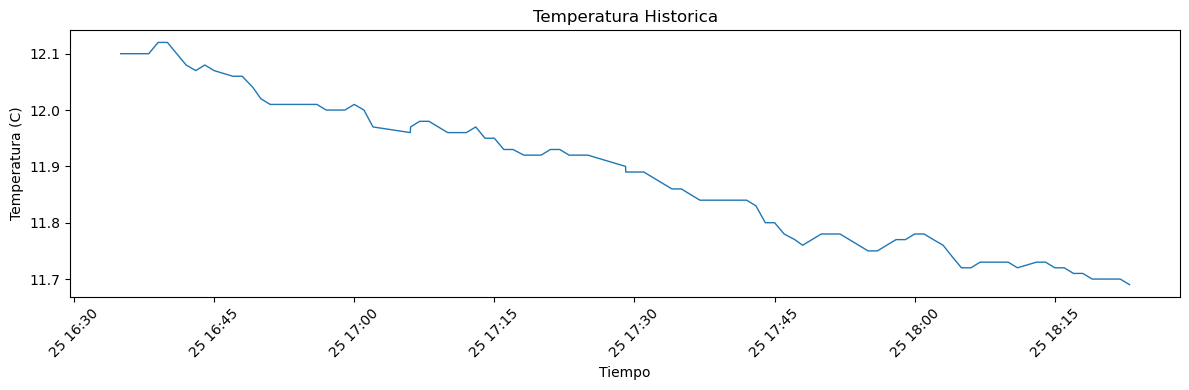

In [9]:
import matplotlib.pyplot as plt

if "created_at" in df.columns and "temperatura" in df.columns:
    df_sorted = df.sort_values("created_at")
    plt.figure(figsize=(12, 4))
    plt.plot(df_sorted["created_at"], df_sorted["temperatura"], linewidth=1)
    plt.title("Temperatura Historica")
    plt.xlabel("Tiempo")
    plt.ylabel("Temperatura (C)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 9. Dato mas reciente (polling opcional)

Esta celda hace polling a Supabase para ver el ultimo registro. No es streaming real, solo verificacion puntual.

In [10]:
import time

print("Obteniendo dato mas reciente cada 5 segundos (Ctrl+C para detener)...\n")
try:
    for i in range(6):
        resp = supabase.table("grupo1_air_quality").select("*").order("created_at", desc=True).limit(1).execute()
        if resp.data:
            d = resp.data[0]
            print(f"[{i+1}] {d.get('created_at')} | Temp: {d.get('temperatura')}C | Hum: {d.get('humedad')}% | IAQ: {d.get('iaq')}")
        time.sleep(5)
except KeyboardInterrupt:
    print("\nPolling detenido")

Obteniendo dato mas reciente cada 5 segundos (Ctrl+C para detener)...

[1] 2026-05-25T18:23:00.052323-05:00 | Temp: 11.69C | Hum: 47.57% | IAQ: 12.84
[2] 2026-05-25T18:23:00.052323-05:00 | Temp: 11.69C | Hum: 47.57% | IAQ: 12.84
[3] 2026-05-25T18:23:00.052323-05:00 | Temp: 11.69C | Hum: 47.57% | IAQ: 12.84
[4] 2026-05-25T18:23:00.052323-05:00 | Temp: 11.69C | Hum: 47.57% | IAQ: 12.84
[5] 2026-05-25T18:23:00.052323-05:00 | Temp: 11.69C | Hum: 47.57% | IAQ: 12.84
[6] 2026-05-25T18:23:00.052323-05:00 | Temp: 11.69C | Hum: 47.57% | IAQ: 12.84
